# Lab 2. Exploratory Data Analysis for Time Series

[Open this lab in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MachineLearning2sda/blob/main/labs/chapter-02-exploratory-data-analysis-lab.ipynb)

This lab accompanies **Chapter 2: Exploratory Data Analysis for Time Series** in
**Modern Time Series Analysis and Sequence Learning**.

The goal of this lab is **independent study**. You should be able to read the explanations, run the code, interpret the figures, and answer the reflection questions without needing an instructor beside you.

## Learning goals

By the end of this lab, you should be able to:

1. Recognize trend, seasonality, changing variance, outliers, and dependence in a time-series plot.
2. Explain the decomposition idea

$$
x_t = \mu_t + y_t,
$$

where $\mu_t$ is a deterministic trend or seasonal mean and $y_t$ is a zero-mean dependent process.
3. Compute and interpret rolling means, rolling standard deviations, and sample autocorrelation.
4. Remove a linear trend by regression and study the residuals.
5. Use first differencing and seasonal differencing to reduce nonstationarity.
6. Use smoothing and simple frequency-domain tools to understand periodic structure.
7. Use AI assistance responsibly to critique an EDA workflow, not to replace your own reasoning.

## How to use this lab

Read each background section first. Then run the code. After each plot, pause and answer the interpretation questions in your own words.


## 0. Setup

This lab uses standard Python packages: `numpy`, `pandas`, `matplotlib`, and `scikit-learn`. These are available in Google Colab.

We will simulate a time series whose true components are known. This makes it easier to learn EDA because we can compare what we estimate from the data with the truth used to generate the data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(7339)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True


## 1. What are we looking for in time-series EDA?

For ordinary tabular data, the order of the rows often does not matter. For time series, the order matters.

A useful first working model is

$$
x_t = \mu_t + y_t,
$$

where:

- $x_t$ is the observed value at time $t$,
- $\mu_t$ is a deterministic mean pattern, such as a trend or seasonal signal,
- $y_t$ is a zero-mean stochastic component, often dependent over time.

The EDA question is:

> What structure is visible in $x_t$ before we build a forecasting model?

Common structure includes:

1. **Trend:** the long-run mean level changes with time.
2. **Seasonality:** similar behavior repeats every fixed period.
3. **Changing variance:** the size of fluctuations changes with time.
4. **Outliers or shocks:** isolated unusual observations.
5. **Autocorrelation:** nearby observations are statistically related.

In this lab, we will generate a synthetic series with trend, seasonality, and autocorrelated noise.


In [2]:
# Time index
n = 240                  # 20 years of monthly data if period = 12
period = 12
t = np.arange(n)

# Deterministic trend component
trend = 50 + 0.08 * t

# Deterministic seasonal component with period 12
seasonal = 3.0 * np.sin(2 * np.pi * t / period) + 1.2 * np.cos(2 * np.pi * t / period)

# Autocorrelated stationary error: AR(1), y_t = phi y_{t-1} + w_t
phi = 0.65
sigma = 1.0
w = rng.normal(0, sigma, size=n)
error = np.zeros(n)
for i in range(1, n):
    error[i] = phi * error[i - 1] + w[i]

# Observed time series
x = trend + seasonal + error

# Put everything in a DataFrame
month_index = pd.date_range("2000-01-01", periods=n, freq="MS")
df = pd.DataFrame({
    "time": t,
    "trend_true": trend,
    "seasonal_true": seasonal,
    "error_true": error,
    "x": x
}, index=month_index)

df.head()


,time,trend_true,seasonal_true,error_true,x
2000-01-01,0,50.00,1.200000,0.000000,51.200000
2000-02-01,1,50.08,2.539230,-0.532150,52.087080
2000-03-01,2,50.16,3.198076,-0.021830,53.336246
2000-04-01,3,50.24,3.000000,0.664025,53.904025
2000-05-01,4,50.32,1.998076,-0.437264,51.880813


## 2. First plot: the time-series plot

The first step in time-series EDA is almost always a time plot.

When you look at the plot, ask:

- Does the mean level seem constant?
- Does the variance seem constant?
- Is there a repeating pattern?
- Are there sudden shocks or outliers?
- Does the series look smooth or noisy?

A time plot is not a formal test, but it gives important modeling clues.


<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4110/593307453.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df.index, df["trend_true"], linestyle="--", linewidth=2, label="true trend $\mu_t$ without seasonality")


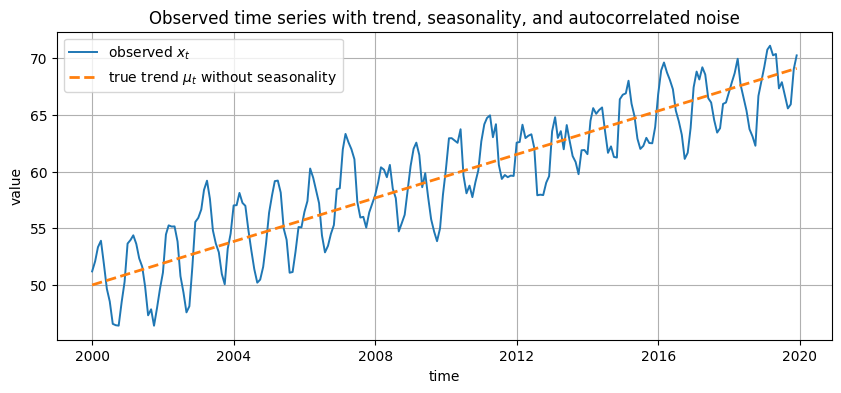

In [3]:
plt.figure()
plt.plot(df.index, df["x"], linewidth=1.4, label="observed $x_t$")
plt.plot(df.index, df["trend_true"], linestyle="--", linewidth=2, label="true trend $\mu_t$ without seasonality")
plt.title("Observed time series with trend, seasonality, and autocorrelated noise")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()


### Interpretation checkpoint

From the plot above:

1. Is the series stationary by visual inspection? Why or why not?
2. Which feature is easiest to see: trend, seasonality, or autocorrelation?
3. If you were forecasting this series, would a white-noise model be reasonable?


## 3. Rolling summaries: local mean and local variance

A stationary series should have a mean and variance that are stable over time. Rolling summaries provide a visual way to check this.

For a window size $m$, the rolling mean is

$$
\bar{x}_{t,m} = \frac{1}{m}\sum_{j=0}^{m-1} x_{t-j}.
$$

The rolling standard deviation is the standard deviation inside the same moving window.

Rolling summaries are exploratory tools. They are not a substitute for model diagnostics, but they are very useful at the beginning.


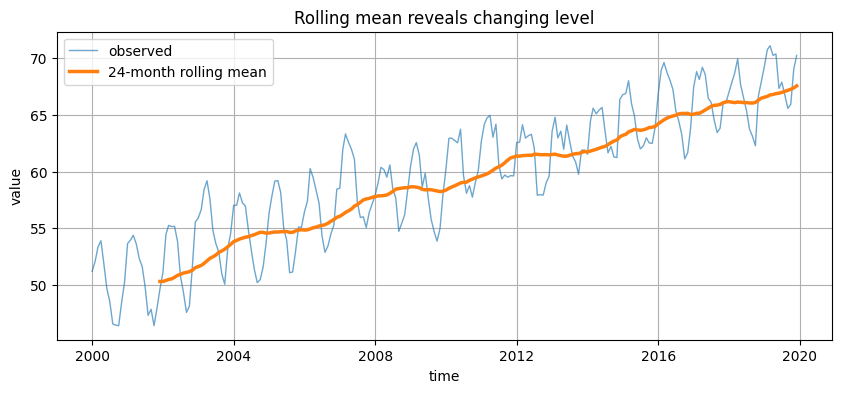

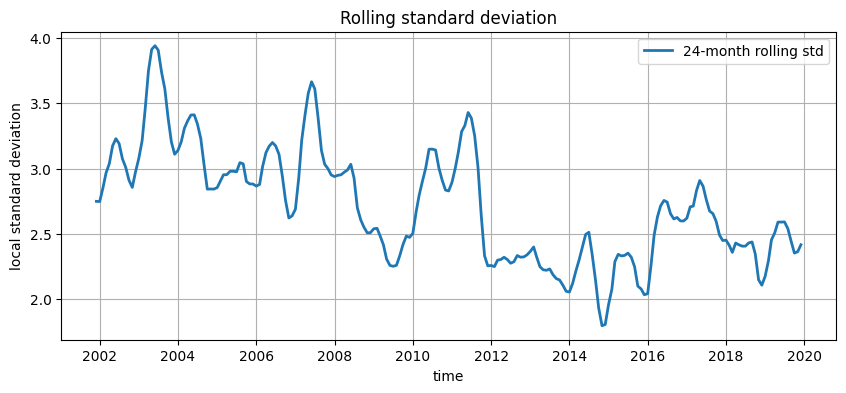

In [4]:
window = 24

df["rolling_mean_24"] = df["x"].rolling(window=window).mean()
df["rolling_std_24"] = df["x"].rolling(window=window).std()

plt.figure()
plt.plot(df.index, df["x"], linewidth=1, alpha=0.65, label="observed")
plt.plot(df.index, df["rolling_mean_24"], linewidth=2.5, label="24-month rolling mean")
plt.title("Rolling mean reveals changing level")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()

plt.figure()
plt.plot(df.index, df["rolling_std_24"], linewidth=2, label="24-month rolling std")
plt.title("Rolling standard deviation")
plt.xlabel("time")
plt.ylabel("local standard deviation")
plt.legend()
plt.show()


### Reflection question

The rolling mean increases over time. What does that suggest about the mean function $\mu_t = E[X_t]$?


## 4. Sample autocorrelation from scratch

Time-series observations are often dependent. The sample autocorrelation function, or sample ACF, estimates linear dependence across lags.

For lag $h$, a common sample autocorrelation estimate is

$$
\widehat{\rho}(h)
=
\frac{\sum_{t=h+1}^{n}(x_t-\bar{x})(x_{t-h}-\bar{x})}
{\sum_{t=1}^{n}(x_t-\bar{x})^2}.
$$

Interpretation:

- $\widehat{\rho}(1)$ measures dependence between neighboring observations.
- Large positive ACF at seasonal lags such as $12, 24, 36$ suggests seasonality.
- A slowly decaying ACF often suggests trend or nonstationarity.


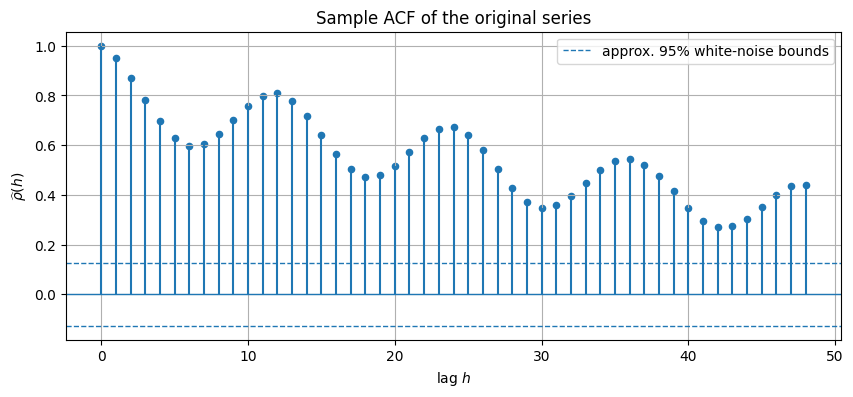

In [5]:
def sample_acf(values, max_lag=40):
    """Compute a simple sample ACF from scratch."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    centered = values - values.mean()
    denom = np.dot(centered, centered)
    acf_values = []
    for h in range(max_lag + 1):
        if h == 0:
            acf_values.append(1.0)
        else:
            acf_values.append(np.dot(centered[h:], centered[:-h]) / denom)
    return np.array(acf_values)


def plot_acf(values, max_lag=40, title="Sample ACF"):
    acf_values = sample_acf(values, max_lag=max_lag)
    lags = np.arange(max_lag + 1)
    bound = 1.96 / np.sqrt(len(pd.Series(values).dropna()))

    plt.figure(figsize=(10, 4))
    plt.axhline(0, linewidth=1)
    plt.axhline(bound, linestyle="--", linewidth=1, label="approx. 95% white-noise bounds")
    plt.axhline(-bound, linestyle="--", linewidth=1)
    plt.vlines(lags, 0, acf_values, linewidth=1.5)
    plt.scatter(lags, acf_values, s=20)
    plt.title(title)
    plt.xlabel("lag $h$")
    plt.ylabel(r"$\widehat{\rho}(h)$")
    plt.legend()
    plt.show()

plot_acf(df["x"], max_lag=48, title="Sample ACF of the original series")


### Interpretation checkpoint

Look at the ACF of the original series.

1. Does it decay quickly or slowly?
2. Do you see large values near seasonal lags such as $12, 24, 36$?
3. Why can trend make the ACF look large even when the stationary error is not extremely persistent?


## 5. Detrending by linear regression

Suppose the observed series has the form

$$
x_t = \beta_0 + \beta_1 t + y_t,
$$

where $y_t$ is a zero-mean stationary process.

A simple way to remove the trend is:

1. Fit the regression $x_t \approx \beta_0 + \beta_1 t$.
2. Compute the residuals

$$
e_t = x_t - \widehat{\mu}_t.
$$

The residuals are not guaranteed to be stationary, but they often reveal the remaining dependence more clearly.


Estimated intercept beta_0: 50.50699624885199
Estimated slope beta_1: 0.07574385135886823


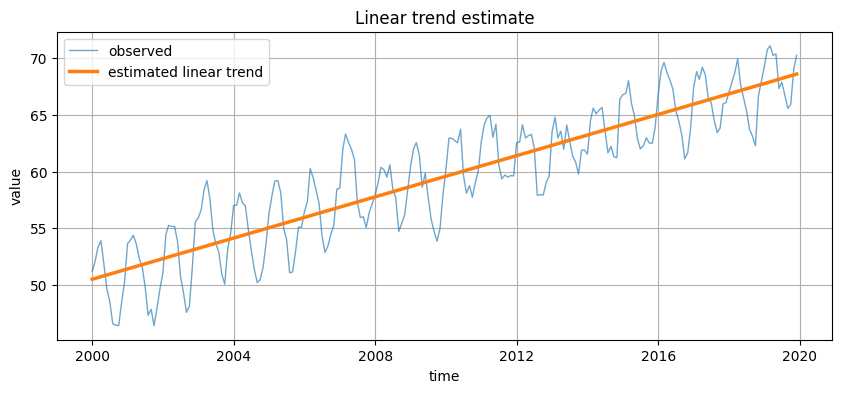

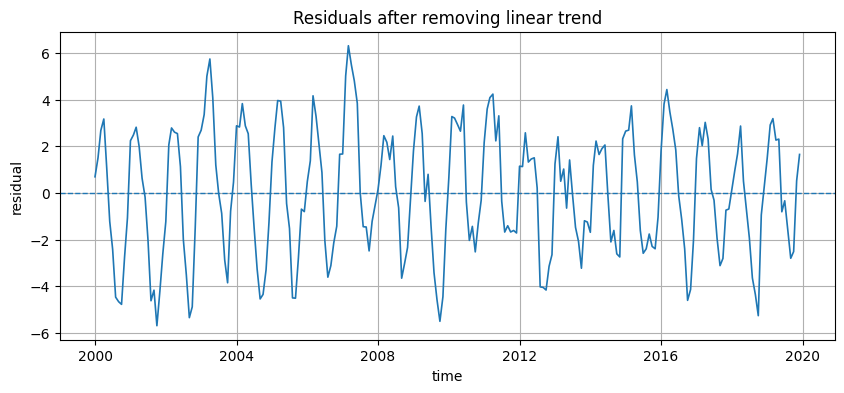

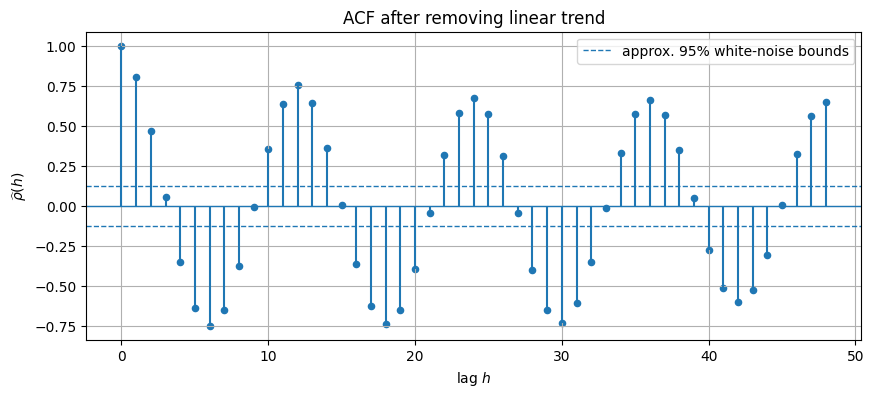

In [6]:
# Fit linear trend model x_t = beta_0 + beta_1 t + residual
X_trend = df[["time"]].values
y = df["x"].values

trend_model = LinearRegression()
trend_model.fit(X_trend, y)

trend_hat = trend_model.predict(X_trend)
df["trend_hat_linear"] = trend_hat
df["resid_after_linear_trend"] = df["x"] - df["trend_hat_linear"]

print("Estimated intercept beta_0:", trend_model.intercept_)
print("Estimated slope beta_1:", trend_model.coef_[0])

plt.figure()
plt.plot(df.index, df["x"], linewidth=1, alpha=0.65, label="observed")
plt.plot(df.index, df["trend_hat_linear"], linewidth=2.5, label="estimated linear trend")
plt.title("Linear trend estimate")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()

plt.figure()
plt.plot(df.index, df["resid_after_linear_trend"], linewidth=1.2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuals after removing linear trend")
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

plot_acf(df["resid_after_linear_trend"], max_lag=48, title="ACF after removing linear trend")


### What changed?

After removing the linear trend, the residuals should fluctuate around zero more clearly. However, seasonality is still present, so the ACF may still show large seasonal spikes.

This is a common lesson in EDA:

> Removing one structure often reveals another structure.


## 6. Regression with trend and seasonal Fourier terms

A deterministic trend-seasonal model can be written as

$$
x_t
=
\beta_0 + \beta_1 t
+ a\sin\left(\frac{2\pi t}{s}\right)
+ b\cos\left(\frac{2\pi t}{s}\right)
+ y_t,
$$

where $s$ is the seasonal period.

For monthly data with yearly seasonality, $s=12$.

This is still linear regression because the unknown parameters are $\beta_0,\beta_1,a,b$. The sine and cosine values are known predictors once $t$ is known.


Intercept: 50.347961448502346
        time: 0.0771
 sin(2πt/12): 3.1273
 cos(2πt/12): 1.1047


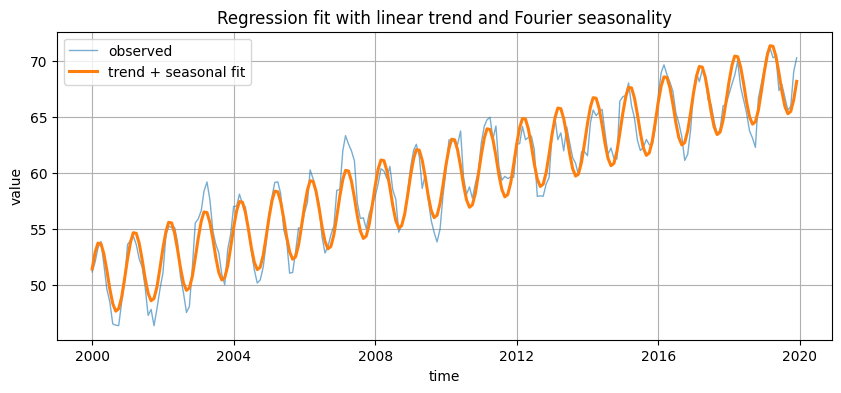

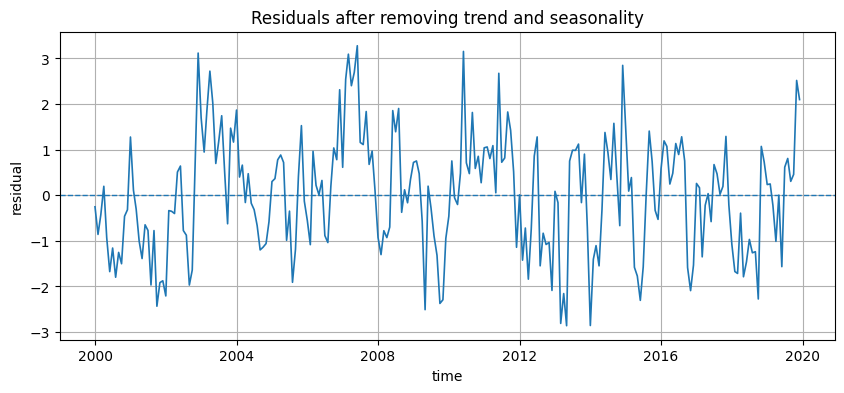

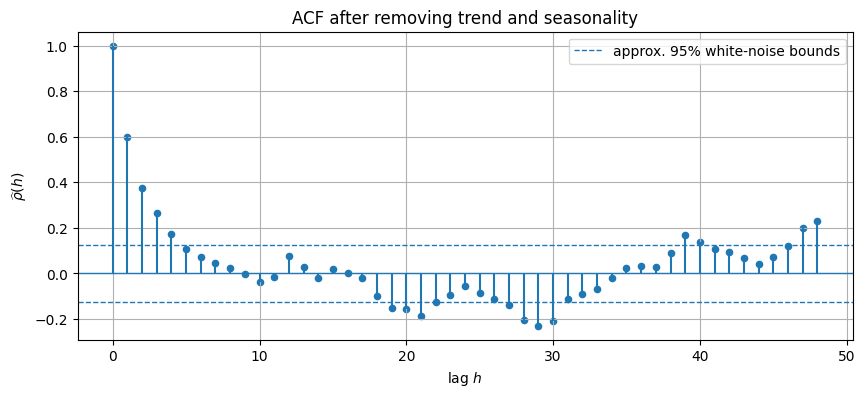

In [7]:
# Build Fourier seasonal features for period 12
sin_12 = np.sin(2 * np.pi * df["time"].values / period)
cos_12 = np.cos(2 * np.pi * df["time"].values / period)

X_trend_seasonal = np.column_stack([
    df["time"].values,
    sin_12,
    cos_12
])

seasonal_model = LinearRegression()
seasonal_model.fit(X_trend_seasonal, y)

fitted_trend_seasonal = seasonal_model.predict(X_trend_seasonal)
df["fitted_trend_seasonal"] = fitted_trend_seasonal
df["resid_after_trend_seasonal"] = df["x"] - df["fitted_trend_seasonal"]

coef_names = ["time", "sin(2πt/12)", "cos(2πt/12)"]
print("Intercept:", seasonal_model.intercept_)
for name, coef in zip(coef_names, seasonal_model.coef_):
    print(f"{name:>12}: {coef:.4f}")

plt.figure()
plt.plot(df.index, df["x"], linewidth=1, alpha=0.6, label="observed")
plt.plot(df.index, df["fitted_trend_seasonal"], linewidth=2.2, label="trend + seasonal fit")
plt.title("Regression fit with linear trend and Fourier seasonality")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()

plt.figure()
plt.plot(df.index, df["resid_after_trend_seasonal"], linewidth=1.2)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuals after removing trend and seasonality")
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

plot_acf(df["resid_after_trend_seasonal"], max_lag=48, title="ACF after removing trend and seasonality")


### Interpretation checkpoint

Compare the ACF before and after removing trend and seasonality.

1. Which ACF has stronger seasonal spikes?
2. Which residual series looks closer to stationary?
3. Why does a remaining positive lag-1 ACF make sense here?


## 7. Differencing

Another way to reduce trend is differencing.

The first difference is

$$
\nabla x_t = x_t - x_{t-1}.
$$

If

$$
x_t = \beta_0 + \beta_1 t + y_t,
$$

then

$$
\nabla x_t = \beta_1 + y_t - y_{t-1}.
$$

So first differencing removes the intercept and converts the linear trend into a constant mean. But differencing also changes the dependence structure of $y_t$.

For seasonal data with period $s$, the seasonal difference is

$$
\nabla_s x_t = x_t - x_{t-s}.
$$


                    x  first_difference  seasonal_difference_12
2000-01-01  51.200000               NaN                     NaN
2000-02-01  52.087080          0.887080                     NaN
2000-03-01  53.336246          1.249166                     NaN
2000-04-01  53.904025          0.567779                     NaN
2000-05-01  51.880813         -2.023213                     NaN
2000-06-01  49.666006         -2.214807                     NaN
2000-07-01  48.549031         -1.116975                     NaN
2000-08-01  46.569764         -1.979267                     NaN
2000-09-01  46.451077         -0.118687                     NaN
2000-10-01  46.412963         -0.038114                     NaN
2000-11-01  48.502778          2.089815                     NaN
2000-12-01  50.271685          1.768907                     NaN
2001-01-01  53.655495          3.383810                2.455495
2001-02-01  53.979940          0.324445                1.892860
2001-03-01  54.384428          0.404488 

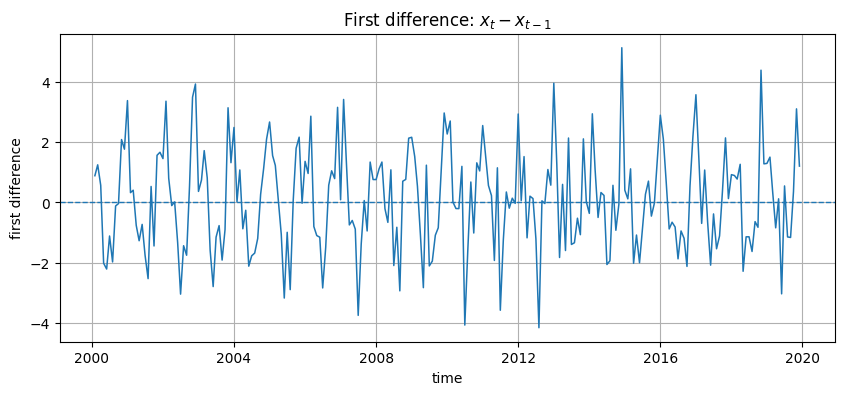

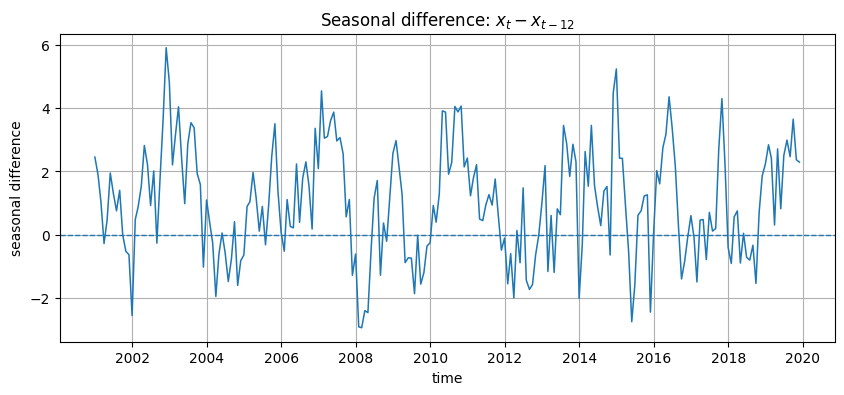

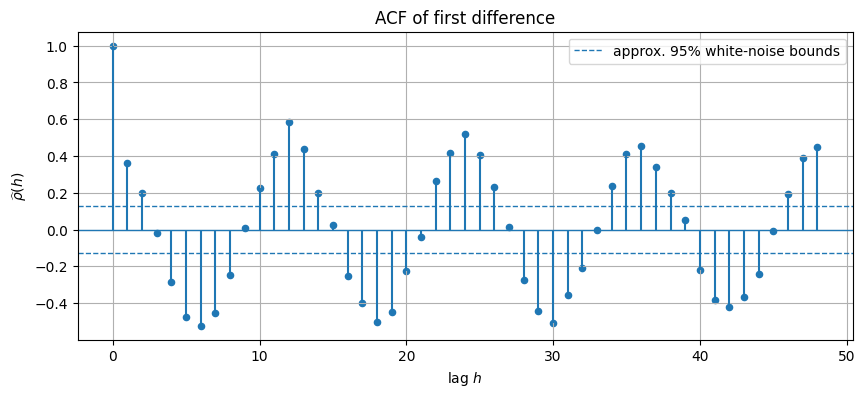

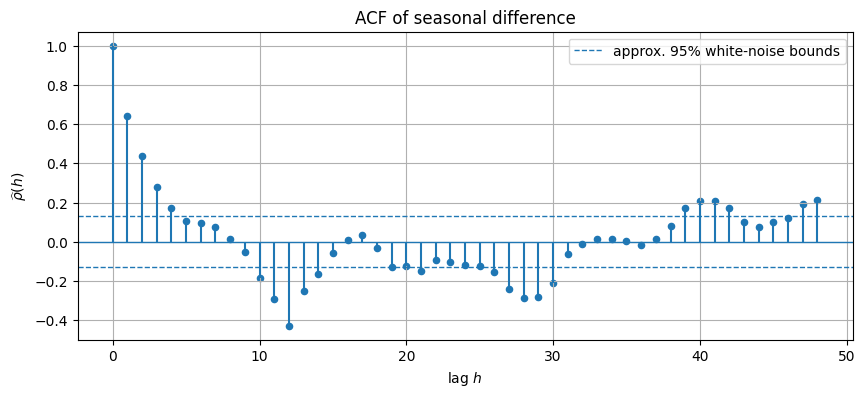

In [8]:
df["first_difference"] = df["x"].diff()
df["seasonal_difference_12"] = df["x"].diff(period)

diff_df = df[["x", "first_difference", "seasonal_difference_12"]].copy()
print(diff_df.head(15))

plt.figure()
plt.plot(df.index, df["first_difference"], linewidth=1.1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("First difference: $x_t - x_{t-1}$")
plt.xlabel("time")
plt.ylabel("first difference")
plt.show()

plt.figure()
plt.plot(df.index, df["seasonal_difference_12"], linewidth=1.1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Seasonal difference: $x_t - x_{t-12}$")
plt.xlabel("time")
plt.ylabel("seasonal difference")
plt.show()

plot_acf(df["first_difference"], max_lag=48, title="ACF of first difference")
plot_acf(df["seasonal_difference_12"], max_lag=48, title="ACF of seasonal difference")


### Detrending versus differencing

Both regression detrending and differencing can reduce nonstationarity, but they do different things.

Regression detrending estimates a deterministic mean $\mu_t$ and studies residuals:

$$
e_t = x_t - \widehat{\mu}_t.
$$

Differencing transforms the series:

$$
\nabla x_t = x_t - x_{t-1}.
$$

Regression detrending is often easier to interpret when the trend is deterministic. Differencing is especially useful when the series behaves like a random walk or has a stochastic trend.


## 8. Smoothing

Smoothing tries to reveal low-frequency structure by reducing short-run noise.

A simple moving average smoother is

$$
\widetilde{x}_t = \frac{1}{m}\sum_{j=0}^{m-1} x_{t-j}.
$$

An exponentially weighted moving average, or EWMA, updates recursively:

$$
\widetilde{x}_t = \alpha x_t + (1-\alpha)\widetilde{x}_{t-1},
\qquad 0<\alpha<1.
$$

Smoothing is useful for visualization, but be careful: if you use future values in a centered smoother, that is not allowed for real-time forecasting.


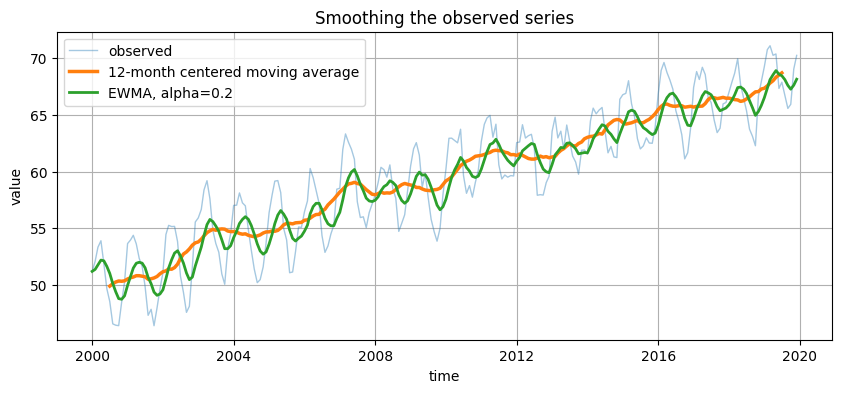

In [9]:
df["ma_12_centered"] = df["x"].rolling(window=12, center=True).mean()
df["ewma_alpha_02"] = df["x"].ewm(alpha=0.2, adjust=False).mean()

plt.figure()
plt.plot(df.index, df["x"], linewidth=1, alpha=0.4, label="observed")
plt.plot(df.index, df["ma_12_centered"], linewidth=2.5, label="12-month centered moving average")
plt.plot(df.index, df["ewma_alpha_02"], linewidth=2.0, label="EWMA, alpha=0.2")
plt.title("Smoothing the observed series")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()


### Reflection question

The centered moving average uses observations both before and after time $t$. Why is that acceptable for exploratory plotting but dangerous for real-time forecasting?


## 9. Detecting periodicity with a simple periodogram

Seasonality can often be detected in the frequency domain.

For a centered finite series $x_0,\ldots,x_{n-1}$, the discrete Fourier transform computes how strongly the data aligns with sinusoidal waves of different frequencies.

A simple periodogram is proportional to

$$
I(\omega_k) = \left| \sum_{t=0}^{n-1} (x_t-\bar{x}) e^{-2\pi i k t/n} \right|^2.
$$

A large periodogram value at frequency $1/12$ suggests a period of $12$ time units.


In [10]:
# Remove only the sample mean before computing the periodogram
x_centered = df["x"].values - df["x"].values.mean()

freqs = np.fft.rfftfreq(n, d=1.0)
fft_values = np.fft.rfft(x_centered)
periodogram = (np.abs(fft_values) ** 2) / n

# Exclude frequency zero when searching for dominant seasonal frequencies
nonzero = freqs > 0
top_indices = np.argsort(periodogram[nonzero])[-5:][::-1]
top_freqs = freqs[nonzero][top_indices]
top_powers = periodogram[nonzero][top_indices]
top_periods = 1 / top_freqs

summary = pd.DataFrame({
    "frequency": top_freqs,
    "period": top_periods,
    "power": top_powers
})
summary


,frequency,period,power
0,0.004167,240.0,1921.567657
1,0.008333,120.0,578.362692
2,0.083333,12.0,547.164639
3,0.012500,80.0,238.042369
4,0.020833,48.0,194.634110


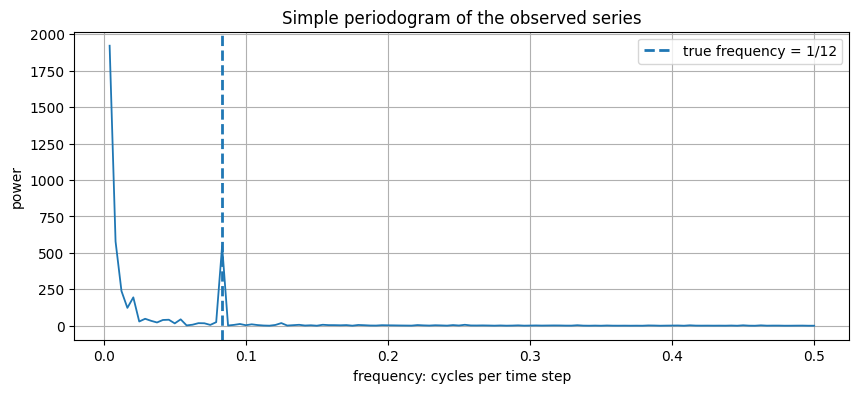

In [11]:
plt.figure()
plt.plot(freqs[nonzero], periodogram[nonzero], linewidth=1.3)
plt.axvline(1 / period, linestyle="--", linewidth=2, label="true frequency = 1/12")
plt.title("Simple periodogram of the observed series")
plt.xlabel("frequency: cycles per time step")
plt.ylabel("power")
plt.legend()
plt.show()


### Interpretation checkpoint

Look at the table of dominant periods and the plot.

1. Is one of the dominant periods close to $12$?
2. Why might trend also create strong low-frequency power?
3. Why should frequency-domain EDA be combined with time-domain plots?


## 10. Outliers and local anomalies

Outliers can distort trends, ACFs, estimated variances, and model diagnostics.

Here we inject two artificial anomalies into the series and use a simple robust rule based on the median absolute deviation, or MAD.

For residual-like values $z_t$, define

$$
\operatorname{MAD} = \operatorname{median}\left(|z_t - \operatorname{median}(z_t)|\right).
$$

A robust z-score can be approximated by

$$
0.6745\frac{z_t - \operatorname{median}(z_t)}{\operatorname{MAD}}.
$$

This is not a universal outlier detector, but it is a good first exploratory tool.


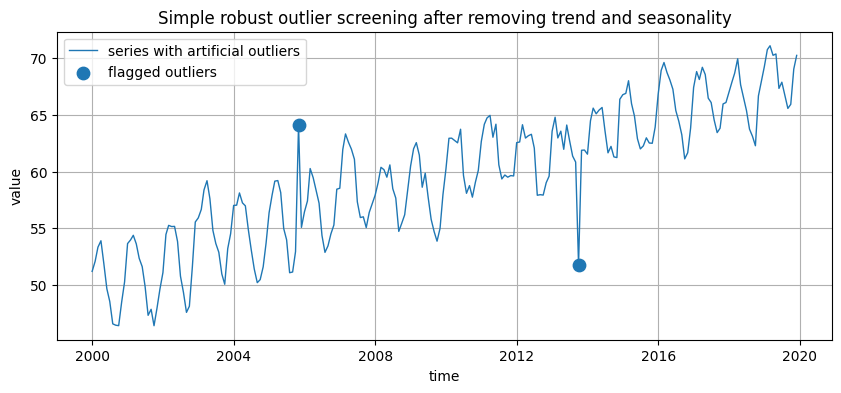

,x_with_outliers,robust_z
2005-11-01,64.114989,7.676295
2013-10-01,51.777152,-6.091867


In [12]:
df_out = df.copy()
df_out["x_with_outliers"] = df_out["x"]
df_out.iloc[70, df_out.columns.get_loc("x_with_outliers")] += 9
df_out.iloc[165, df_out.columns.get_loc("x_with_outliers")] -= 8

# Remove a simple trend-seasonal fit first, then look for unusual residuals
X_out = X_trend_seasonal
model_out = LinearRegression().fit(X_out, df_out["x_with_outliers"].values)
resid_out = df_out["x_with_outliers"].values - model_out.predict(X_out)

median_resid = np.median(resid_out)
mad = np.median(np.abs(resid_out - median_resid))
robust_z = 0.6745 * (resid_out - median_resid) / mad
outlier_flag = np.abs(robust_z) > 3.5

df_out["robust_z"] = robust_z
df_out["outlier_flag"] = outlier_flag

plt.figure()
plt.plot(df_out.index, df_out["x_with_outliers"], linewidth=1, label="series with artificial outliers")
plt.scatter(
    df_out.index[df_out["outlier_flag"]],
    df_out.loc[df_out["outlier_flag"], "x_with_outliers"],
    s=80,
    label="flagged outliers"
)
plt.title("Simple robust outlier screening after removing trend and seasonality")
plt.xlabel("time")
plt.ylabel("value")
plt.legend()
plt.show()

df_out.loc[df_out["outlier_flag"], ["x_with_outliers", "robust_z"]]


### Caution

Outliers are not always mistakes. They may correspond to real events: policy changes, market crashes, sensor failures, holidays, system outages, or regime changes.

A good time-series analyst should ask:

- Is this a data error?
- Is this a real event?
- Should it be modeled as an intervention or holiday effect?
- Would it be available at forecasting time?


## 11. A compact EDA workflow

For a new time series, a practical first workflow is:

1. Plot the raw series.
2. Check rolling mean and rolling standard deviation.
3. Plot the sample ACF.
4. Look for trend and seasonality.
5. Try a simple transformation if variance changes strongly.
6. Try detrending, differencing, or seasonal differencing.
7. Re-check the residuals or transformed series.
8. Document what you found before fitting a model.

The goal is not to force the data into a model immediately. The goal is to understand what structure a model must explain.


In [13]:
def eda_summary(values, max_lag=24):
    values = pd.Series(values).dropna()
    acf_values = sample_acf(values.values, max_lag=max_lag)
    return pd.Series({
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(ddof=1),
        "min": values.min(),
        "max": values.max(),
        "acf_lag_1": acf_values[1],
        "acf_lag_12": acf_values[12] if max_lag >= 12 else np.nan
    })

summary_table = pd.DataFrame({
    "original": eda_summary(df["x"], max_lag=24),
    "linear_detrended": eda_summary(df["resid_after_linear_trend"], max_lag=24),
    "trend_seasonal_resid": eda_summary(df["resid_after_trend_seasonal"], max_lag=24),
    "first_difference": eda_summary(df["first_difference"], max_lag=24),
    "seasonal_difference_12": eda_summary(df["seasonal_difference_12"], max_lag=24)
})

summary_table.round(3)


,original,linear_detrended,trend_seasonal_resid,first_difference,seasonal_difference_12
n,240.000,240.000,240.000,239.000,228.000
mean,59.558,-0.000,0.000,0.080,0.990
std,5.899,2.674,1.279,1.675,1.747
min,46.406,-5.692,-2.861,-4.166,-2.947
max,71.114,6.311,3.280,5.142,5.919
acf_lag_1,0.949,0.804,0.599,0.360,0.643
acf_lag_12,0.810,0.752,0.075,0.585,-0.429


## 12. AI-assisted EDA: useful prompts

AI tools can help you think, but they should not replace your analysis. Use AI as a reviewer.

Here are prompts you can use after completing your own EDA.

### Prompt A: structure diagnosis

> I have a time series with an increasing rolling mean, seasonal spikes at lags 12 and 24 in the ACF, and residual lag-1 autocorrelation after removing trend and seasonality. What models should I consider, and what diagnostics should I check next?

### Prompt B: leakage check

> I used a centered moving average to smooth a time series. Explain why this is acceptable for visualization but not for real-time forecasting. Give a leakage-safe alternative.

### Prompt C: code review

> Review this time-series EDA code. Identify any step that uses future information, changes the index incorrectly, or compares models unfairly.

### Rule for this course

Every AI suggestion must be checked against:

1. the time order of the data,
2. the information available at forecasting time,
3. the mathematical definition of the transformation,
4. residual diagnostics.


## 13. Exercises

### Exercise 1: Change the strength of the trend

Return to the simulation cell and change the trend slope from `0.08` to `0.20`. Re-run the lab.

- What happens to the original ACF?
- Does detrending become more important?

### Exercise 2: Change the seasonal period

Change the period from `12` to `6`.

- Which ACF lags become important?
- Which periodogram frequency becomes dominant?

### Exercise 3: Compare detrending and differencing

Using the summary table, compare:

- residuals after trend-seasonal regression,
- first differences,
- seasonal differences.

Which one looks most stationary? Explain your answer.

### Exercise 4: Outlier sensitivity

Inject a larger positive outlier and observe how it changes:

- the time plot,
- the rolling standard deviation,
- the ACF,
- the fitted trend-seasonal model.

### Exercise 5: Real-data extension

Find a public monthly or daily time series. Apply the same EDA workflow:

1. raw time plot,
2. rolling summaries,
3. ACF,
4. detrending or differencing,
5. smoothing,
6. frequency-domain check,
7. short written interpretation.


## 14. Lab checklist

Before leaving this lab, make sure you can do the following without looking at the solutions:

- [ ] Explain why time-series EDA begins with a time plot.
- [ ] Define trend, seasonality, and autocorrelation in plain language.
- [ ] Compute a sample ACF from scratch.
- [ ] Remove a linear trend using regression.
- [ ] Add sine and cosine seasonal features to a regression model.
- [ ] Compute first differences and seasonal differences.
- [ ] Explain the difference between smoothing for visualization and smoothing for forecasting.
- [ ] Use a periodogram to detect a dominant seasonal period.
- [ ] Explain why outliers require contextual judgment.
- [ ] Ask an AI assistant to critique your workflow and then verify its suggestions mathematically.
